# VAE-Based Image Generation in PyTorch

This notebook builds a simple Variational Autoencoder (VAE) for image generation using PyTorch.
It trains on MNIST, visualizes reconstructions, and samples new images from the latent space.

VAE : https://www.youtube.com/watch?v=qJeaCHQ1k2w

## 1. Imports

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


Using device: cuda


## 2. Hyperparameters

In [2]:
batch_size = 128
latent_dim = 20
hidden_dim = 400
lr = 1e-3
epochs = 25
image_size = 28 * 28


## 3. Dataset

In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Train samples: 60000
Test samples: 10000


## 4. Define the VAE

The encoder predicts the mean and log-variance of the latent distribution.
The decoder maps latent samples back to image space.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class VAE(nn.Module):
    def __init__(
        self,
        image_size=784,
        hidden_dims=(512, 256, 128),
        latent_dim=32,
        dropout=0.1,
    ):
        super().__init__()

        h1, h2, h3 = hidden_dims

        # Encoder
        self.enc_fc1 = nn.Linear(image_size, h1)
        self.enc_bn1 = nn.BatchNorm1d(h1)

        self.enc_fc2 = nn.Linear(h1, h2)
        self.enc_bn2 = nn.BatchNorm1d(h2)

        self.enc_fc3 = nn.Linear(h2, h3)
        self.enc_bn3 = nn.BatchNorm1d(h3)

        self.fc_mu = nn.Linear(h3, latent_dim)
        self.fc_logvar = nn.Linear(h3, latent_dim)

        # Decoder
        self.dec_fc1 = nn.Linear(latent_dim, h3)
        self.dec_bn1 = nn.BatchNorm1d(h3)

        self.dec_fc2 = nn.Linear(h3, h2)
        self.dec_bn2 = nn.BatchNorm1d(h2)

        self.dec_fc3 = nn.Linear(h2, h1)
        self.dec_bn3 = nn.BatchNorm1d(h1)

        self.out_fc = nn.Linear(h1, image_size)

        self.dropout = nn.Dropout(dropout)

    def encode(self, x):
        h = F.relu(self.enc_bn1(self.enc_fc1(x)))
        h = self.dropout(h)

        h = F.relu(self.enc_bn2(self.enc_fc2(h)))
        h = self.dropout(h)

        h = F.relu(self.enc_bn3(self.enc_fc3(h)))
        h = self.dropout(h)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.dec_bn1(self.dec_fc1(z)))
        h = self.dropout(h)

        h = F.relu(self.dec_bn2(self.dec_fc2(h)))
        h = self.dropout(h)

        h = F.relu(self.dec_bn3(self.dec_fc3(h)))
        h = self.dropout(h)

        x_hat = torch.sigmoid(self.out_fc(h))
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


model = VAE(
    image_size=image_size,
    hidden_dims=(512, 256, 128),
    latent_dim=latent_dim,
    dropout=0.1,
).to(device)

print(model)

VAE(
  (enc_fc1): Linear(in_features=784, out_features=512, bias=True)
  (enc_bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_fc2): Linear(in_features=512, out_features=256, bias=True)
  (enc_bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_fc3): Linear(in_features=256, out_features=128, bias=True)
  (enc_bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc_mu): Linear(in_features=128, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=20, bias=True)
  (dec_fc1): Linear(in_features=20, out_features=128, bias=True)
  (dec_bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dec_fc2): Linear(in_features=128, out_features=256, bias=True)
  (dec_bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dec_fc3): Linear(in_features=256, out_features=512, bias=True)


## 5. Loss Function

A VAE combines:
- reconstruction loss
- KL divergence regularization

In [5]:
def vae_loss(x_hat, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

## 6. Training Loop

In [6]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    for images, _ in loader:
        images = images.to(device)
        x = images.view(images.size(0), -1)

        optimizer.zero_grad()
        x_hat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x_hat, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    for images, _ in loader:
        images = images.to(device)
        x = images.view(images.size(0), -1)
        x_hat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x_hat, x, mu, logvar)

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n


history = {
    'train_loss': [], 'train_recon': [], 'train_kl': [],
    'test_loss': [], 'test_recon': [], 'test_kl': []
}

for epoch in range(1, epochs + 1):
    train_loss, train_recon, train_kl = train_epoch(model, train_loader, optimizer, device)
    test_loss, test_recon, test_kl = eval_epoch(model, test_loader, device)

    history['train_loss'].append(train_loss)
    history['train_recon'].append(train_recon)
    history['train_kl'].append(train_kl)
    history['test_loss'].append(test_loss)
    history['test_recon'].append(test_recon)
    history['test_kl'].append(test_kl)

    print(
        f'Epoch {epoch:02d}/{epochs} | '
        f'train loss: {train_loss:.4f} | test loss: {test_loss:.4f} | '
        f'train recon: {train_recon:.4f} | train kl: {train_kl:.4f}'
    )

Epoch 01/25 | train loss: 158.1923 | test loss: 126.5704 | train recon: 146.4516 | train kl: 11.7406
Epoch 02/25 | train loss: 131.4988 | test loss: 118.4062 | train recon: 117.2887 | train kl: 14.2101
Epoch 03/25 | train loss: 127.2404 | test loss: 115.1108 | train recon: 112.5039 | train kl: 14.7366
Epoch 04/25 | train loss: 124.9295 | test loss: 113.5449 | train recon: 109.9226 | train kl: 15.0069
Epoch 05/25 | train loss: 123.6523 | test loss: 112.1489 | train recon: 108.4688 | train kl: 15.1835
Epoch 06/25 | train loss: 122.7216 | test loss: 111.4224 | train recon: 107.4213 | train kl: 15.3002
Epoch 07/25 | train loss: 121.8831 | test loss: 110.4142 | train recon: 106.4872 | train kl: 15.3959
Epoch 08/25 | train loss: 121.2547 | test loss: 110.2133 | train recon: 105.7562 | train kl: 15.4985
Epoch 09/25 | train loss: 120.7277 | test loss: 109.5900 | train recon: 105.1729 | train kl: 15.5548
Epoch 10/25 | train loss: 120.3147 | test loss: 109.0222 | train recon: 104.6951 | train kl

## 7. Plot Training Curves

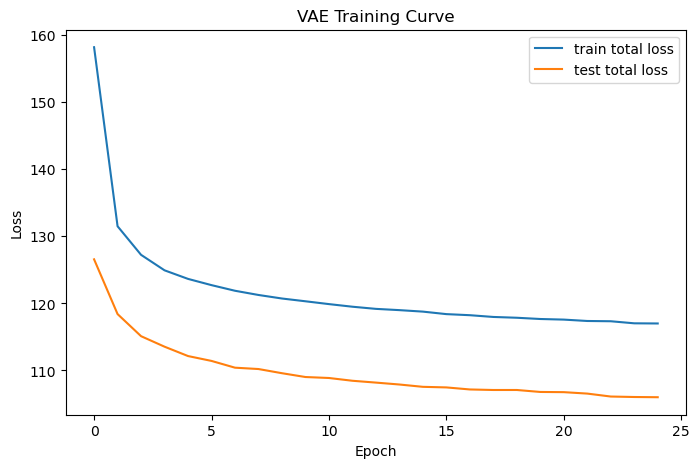

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='train total loss')
plt.plot(history['test_loss'], label='test total loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training Curve')
plt.legend()
plt.show()

## 8. Reconstruction Results

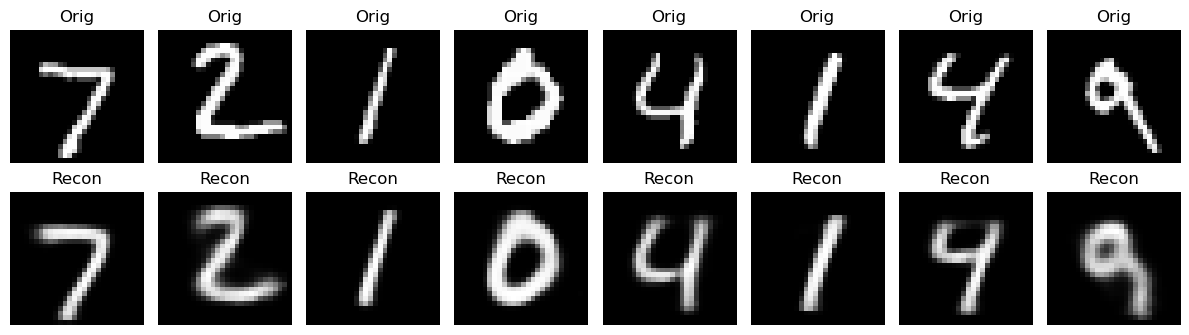

In [8]:
@torch.no_grad()
def show_reconstructions(model, loader, device, n=8):
    model.eval()
    images, _ = next(iter(loader))
    images = images[:n].to(device)
    x = images.view(images.size(0), -1)
    x_hat, _, _ = model(x)

    recon = x_hat.view(-1, 1, 28, 28).cpu()
    originals = images.cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.5 * n, 3.5))
    for i in range(n):
        axes[0, i].imshow(originals[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title('Orig')

        axes[1, i].imshow(recon[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title('Recon')

    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader, device)

## 9. Generate New Images from the Latent Space

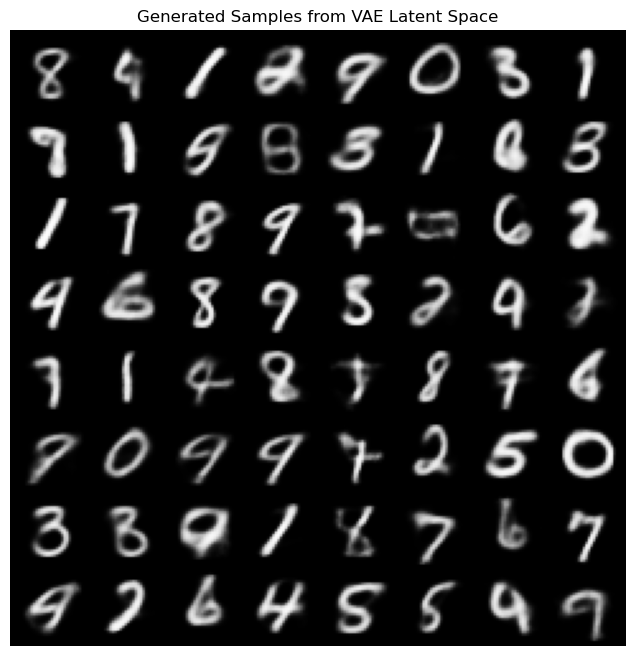

In [9]:
@torch.no_grad()
def sample_images(model, num_samples=64, latent_dim=20, device='cpu'):
    model.eval()
    z = torch.randn(num_samples, latent_dim).to(device)
    samples = model.decode(z)
    samples = samples.view(num_samples, 1, 28, 28).cpu()
    return samples

samples = sample_images(model, num_samples=64, latent_dim=latent_dim, device=device)
grid = make_grid(samples, nrow=8, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('Generated Samples from VAE Latent Space')
plt.show()

## 10. Latent Space Interpolation

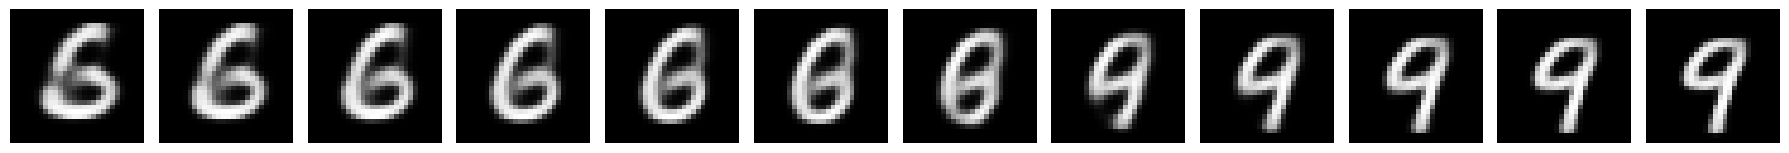

In [11]:
@torch.no_grad()
def interpolate_latent(model, device, steps=10, latent_dim=20):
    model.eval()
    z1 = torch.randn(1, latent_dim).to(device)
    z2 = torch.randn(1, latent_dim).to(device)

    alphas = torch.linspace(0, 1, steps).to(device)
    zs = torch.cat([(1 - a) * z1 + a * z2 for a in alphas], dim=0)
    imgs = model.decode(zs).view(steps, 1, 28, 28).cpu()

    fig, axes = plt.subplots(1, steps, figsize=(1.5 * steps, 2))
    for i in range(steps):
        axes[i].imshow(imgs[i].squeeze(), cmap='gray')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

interpolate_latent(model, device=device, steps=12, latent_dim=latent_dim)

## 11. Save the Trained Model

In [12]:
save_path = 'vae_mnist.pth'
torch.save(model.state_dict(), save_path)
print(f'Model saved to {save_path}')

Model saved to vae_mnist.pth


## 12. Next Steps

You can extend this notebook by:
- replacing the MLP VAE with a convolutional VAE
- training 
- visualizing the latent embedding with t-SNE 

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CNNVAE(nn.Module):
    def __init__(self, in_channels=1, latent_dim=32, input_size=28):
        super().__init__()

        self.in_channels = in_channels
        self.latent_dim = latent_dim
        self.input_size = input_size

        # Encoder: (B, C, 28, 28) -> (B, 256, 4, 4)
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),            # 14 -> 7
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),           # 7 -> 4
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),          # 4 -> 4
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        self.feature_dim = 256 * 4 * 4

        self.fc_mu = nn.Linear(self.feature_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.feature_dim, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim, self.feature_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=1, padding=1),          # 4 -> 4
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),  # 4 -> 7
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),             # 7 -> 14
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(32, in_channels, kernel_size=4, stride=2, padding=1),    # 14 -> 28
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h = torch.flatten(h, start_dim=1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 256, 4, 4)
        x_hat = self.decoder(h)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 32
model = CNNVAE(in_channels=1, latent_dim=latent_dim, input_size=28).to(device)

x = torch.randn(16, 1, 28, 28).to(device)
x_hat, mu, logvar = model(x)

print("input shape:", x.shape)
print("recon shape:", x_hat.shape)
print("mu shape:", mu.shape)
print("logvar shape:", logvar.shape)

input shape: torch.Size([16, 1, 28, 28])
recon shape: torch.Size([16, 1, 28, 28])
mu shape: torch.Size([16, 32])
logvar shape: torch.Size([16, 32])


In [21]:
def vae_loss(x_hat, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction="sum")
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss

In [22]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, total_recon, total_kl = 0.0, 0.0, 0.0

    for images, _ in loader:
        x = images.to(device)   # shape: [B, 1, 28, 28]

        optimizer.zero_grad()
        x_hat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x_hat, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss, total_recon, total_kl = 0.0, 0.0, 0.0

    for images, _ in loader:
        x = images.to(device)

        x_hat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x_hat, x, mu, logvar)

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n


history = {
    'train_loss': [], 'train_recon': [], 'train_kl': [],
    'test_loss': [], 'test_recon': [], 'test_kl': []
}

for epoch in range(1, epochs + 1):
    train_loss, train_recon, train_kl = train_epoch(model, train_loader, optimizer, device)
    test_loss, test_recon, test_kl = eval_epoch(model, test_loader, device)

    history['train_loss'].append(train_loss)
    history['train_recon'].append(train_recon)
    history['train_kl'].append(train_kl)
    history['test_loss'].append(test_loss)
    history['test_recon'].append(test_recon)
    history['test_kl'].append(test_kl)

    print(
        f'Epoch {epoch:02d}/{epochs} | '
        f'train loss: {train_loss:.4f} | test loss: {test_loss:.4f} | '
        f'train recon: {train_recon:.4f} | train kl: {train_kl:.4f}'
    )

Epoch 01/25 | train loss: 109.0787 | test loss: 106.2328 | train recon: 83.5044 | train kl: 25.5742
Epoch 02/25 | train loss: 105.5717 | test loss: 104.0421 | train recon: 79.8186 | train kl: 25.7531
Epoch 03/25 | train loss: 103.8034 | test loss: 105.5467 | train recon: 78.1227 | train kl: 25.6807
Epoch 04/25 | train loss: 102.4031 | test loss: 100.9415 | train recon: 76.7907 | train kl: 25.6124
Epoch 05/25 | train loss: 101.5421 | test loss: 100.6323 | train recon: 76.0135 | train kl: 25.5286
Epoch 06/25 | train loss: 100.8565 | test loss: 100.2745 | train recon: 75.4400 | train kl: 25.4165
Epoch 07/25 | train loss: 100.4234 | test loss: 99.5410 | train recon: 75.0932 | train kl: 25.3302
Epoch 08/25 | train loss: 99.8688 | test loss: 99.1168 | train recon: 74.6134 | train kl: 25.2554
Epoch 09/25 | train loss: 99.4657 | test loss: 99.0220 | train recon: 74.3144 | train kl: 25.1513
Epoch 10/25 | train loss: 99.1420 | test loss: 98.6634 | train recon: 74.0331 | train kl: 25.1089
Epoch 1

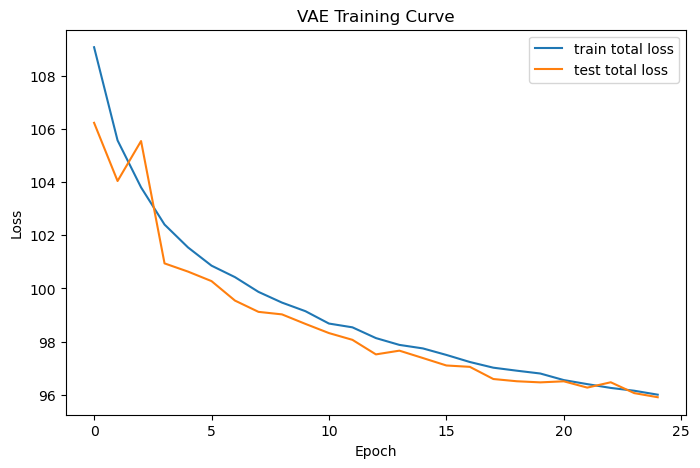

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='train total loss')
plt.plot(history['test_loss'], label='test total loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training Curve')
plt.legend()
plt.show()

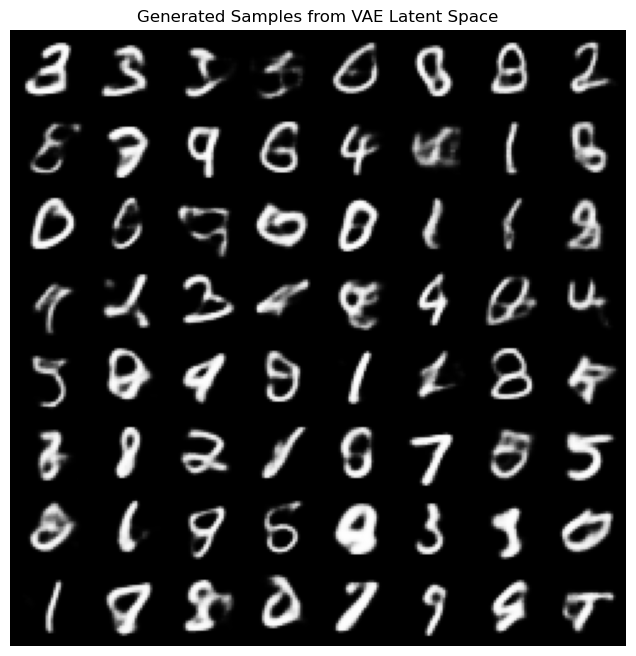

In [23]:
@torch.no_grad()
def sample_images(model, num_samples=64, latent_dim=20, device='cpu'):
    model.eval()
    z = torch.randn(num_samples, latent_dim).to(device)
    samples = model.decode(z)
    samples = samples.view(num_samples, 1, 28, 28).cpu()
    return samples

samples = sample_images(model, num_samples=64, latent_dim=latent_dim, device=device)
grid = make_grid(samples, nrow=8, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('Generated Samples from VAE Latent Space')
plt.show()

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a technique used to visualize high-dimensional data, such as latent vectors from a VAE, in a lower-dimensional space (usually 2D). It works by converting the similarity between data points into probabilities and then trying to preserve these similarities when mapping the data to a lower dimension. Points that are close together in the original space remain close in the visualization, which makes it especially useful for identifying clusters or patterns. However, while t-SNE preserves local structure well, it may distort global relationships between clusters.

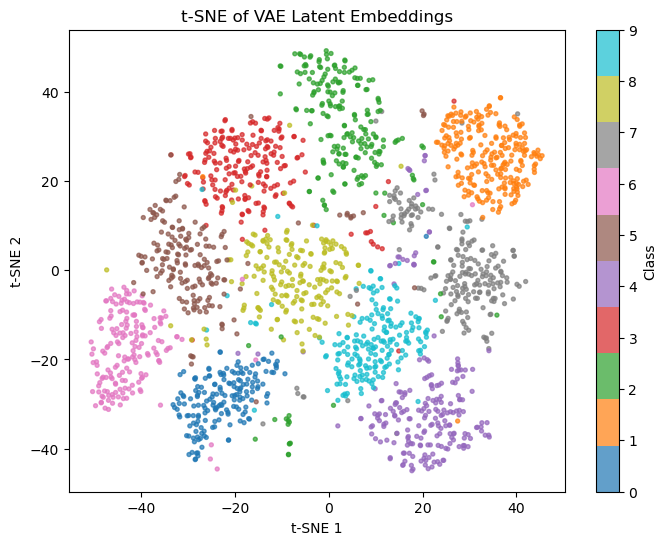

In [26]:
# t-SNE visualization of VAE latent embeddings
# Assumes:
#   - model is your trained CNNVAE
#   - test_loader exists
#   - device exists
#   - labels are available from the loader

import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


@torch.no_grad()
def collect_latents(model, loader, device, use_mean=True, max_samples=2000):
    model.eval()

    all_z = []
    all_y = []
    total = 0

    for images, labels in loader:
        images = images.to(device)

        mu, logvar = model.encode(images)
        z = mu if use_mean else model.reparameterize(mu, logvar)

        all_z.append(z.cpu())
        all_y.append(labels.cpu())

        total += images.size(0)
        if total >= max_samples:
            break

    Z = torch.cat(all_z, dim=0)[:max_samples]
    Y = torch.cat(all_y, dim=0)[:max_samples]
    return Z.numpy(), Y.numpy()


# collect latent vectors
Z, Y = collect_latents(model, test_loader, device, use_mean=True, max_samples=2000)

# run t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
Z_2d = tsne.fit_transform(Z)

# plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=Y, s=8, alpha=0.7, cmap="tab10")
plt.colorbar(scatter, label="Class")
plt.title("t-SNE of VAE Latent Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()